In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

In [6]:
er = pd.read_csv("../datasets/processed/er_feature_engineered.csv")

In [7]:
X = er.drop(columns=["Patient Waittime"], errors="ignore")
y = er["Patient Waittime"]

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [9]:
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [10]:
model = joblib.load("../models/wait_time_prediction_model.pkl")

In [11]:
rf_predictions = model.predict(X_test)

In [12]:
comparison = pd.DataFrame({
    "Actual": y_test,
    "Predicted": rf_predictions
})

comparison.head(10)

,Actual,Predicted
4502,60,39.50
3130,35,29.19
7559,26,32.64
3685,51,30.01
1790,17,35.49
5840,19,36.33
8486,22,30.34
7231,20,34.86
8366,50,39.22
7379,30,45.79


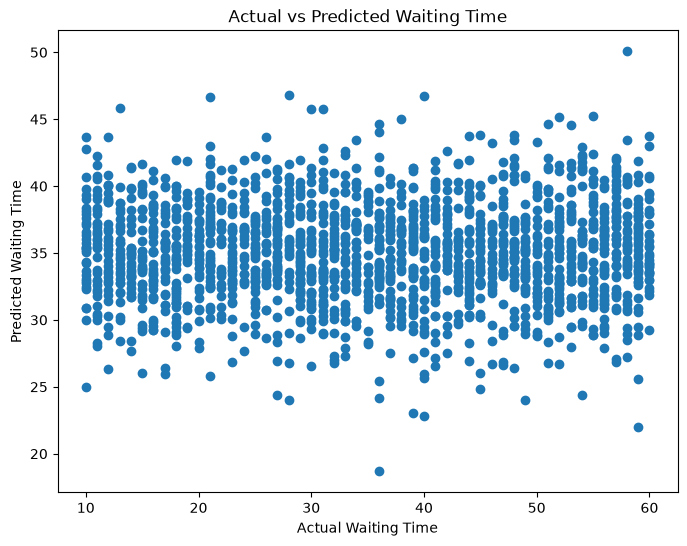

In [13]:
plt.figure(figsize=(8,6))

plt.scatter(y_test, rf_predictions)

plt.xlabel("Actual Waiting Time")

plt.ylabel("Predicted Waiting Time")

plt.title("Actual vs Predicted Waiting Time")

plt.show()

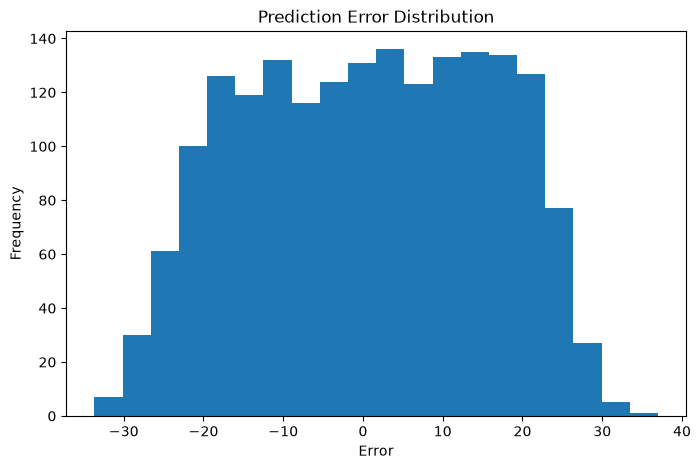

In [14]:
errors = y_test - rf_predictions

plt.figure(figsize=(8,5))

plt.hist(errors, bins=20)

plt.title("Prediction Error Distribution")

plt.xlabel("Error")

plt.ylabel("Frequency")

plt.show()

In [17]:
import joblib

model = joblib.load("../models/wait_time_prediction_model.pkl")

In [16]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
1,Patient Age,0.241644
9,Admission_Day,0.183424
8,Admission_Month,0.122021
2,Patient Race,0.101607
10,Admission_Weekday,0.100214
5,Patient Satisfaction Score,0.073129
3,Department Referral,0.070562
0,Patient Gender,0.036732
4,Patient Admission Flag,0.032748
7,Admission_Year,0.028401


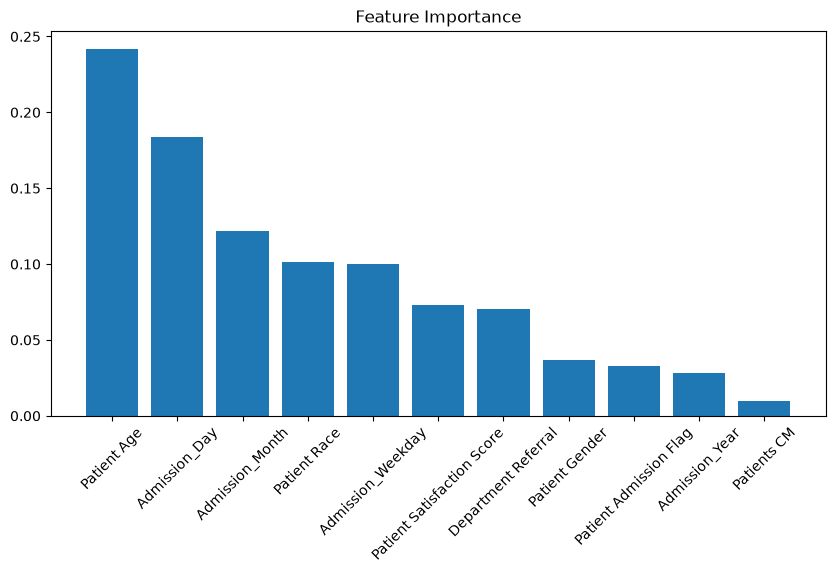

In [18]:
plt.figure(figsize=(10,5))

plt.bar(
    importance["Feature"],
    importance["Importance"]
)

plt.xticks(rotation=45)

plt.title("Feature Importance")

plt.show()

In [20]:
print("Random Forest Evaluation")

print("MAE :", mean_absolute_error(y_test, rf_predictions))

print("MSE :", mean_squared_error(y_test, rf_predictions))

print("R2 :", r2_score(y_test, rf_predictions))

Random Forest Evaluation
MAE : 12.927641178597252
MSE : 227.2176696775428
R2 : -0.059347989861299855


In [21]:
print("="*60)
print("Model Evaluation Completed Successfully")
print("="*60)
print("Random Forest is selected as the final model for CareFlow AI.")

Model Evaluation Completed Successfully
Random Forest is selected as the final model for CareFlow AI.
